# Detecção de Anomalias em Transações em Python
## Bootcamp Afya Dados — DIO / Anhanguera

Este notebook implementa um pipeline completo de detecção de fraudes bancárias, cobrindo:
- Exploração e pré-processamento dos dados
- Tratamento de classes desbalanceadas
- Modelagem com múltiplos algoritmos
- Avaliação com métricas adequadas
- Explicabilidade com SHAP

**Dataset:** Credit Card Fraud — TensorFlow Public Storage  
**Autora:** Isadora Garcia Ferrão (professora referência)

---
## 0. Configurações e Constantes

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
import shap

# ── Constantes ──────────────────────────────────────────────────────────────
DATASET_URL: str = (
    "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
)
RANDOM_STATE: int = 42
TEST_SIZE: float = 0.30
N_ESTIMATORS: int = 100
MAX_DEPTH: int = 10
SMOTE_SAMPLING_STRATEGY: float = 0.5  # fraudes passam a ser 50% das legítimas

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(RANDOM_STATE)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
# MÓDULO 1 — Primeiros Passos no Projeto
## 1.1 Carregamento dos Dados

In [2]:
def load_data(url: str) -> pd.DataFrame:
    """Carrega o dataset de transações a partir de uma URL CSV.

    Parameters
    ----------
    url : str
        URL pública do arquivo CSV.

    Returns
    -------
    pd.DataFrame
        DataFrame com os dados brutos.
    """
    print(f'Baixando dataset de:\n  {url}')
    df = pd.read_csv(url)
    print(f'Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
    return df


df = load_data(DATASET_URL)

Baixando dataset de:
  https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Dataset carregado: 284,807 linhas × 31 colunas


## 1.2 Análise Exploratória (EDA)

In [3]:
print('=== Primeiras linhas ===')
df.head()

=== Primeiras linhas ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print('=== Tipos e valores nulos ===')
print(df.dtypes)
print(f'\nValores nulos por coluna:\n{df.isnull().sum()}')

=== Tipos e valores nulos ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Valores nulos por coluna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0

In [5]:
print('=== Estatísticas descritivas ===')
df.describe().T

=== Estatísticas descritivas ===


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


=== Distribuição das Classes ===
Legítimas  (0): 284,315  (99.8273%)
Fraudes    (1):     492  (0.1727%)


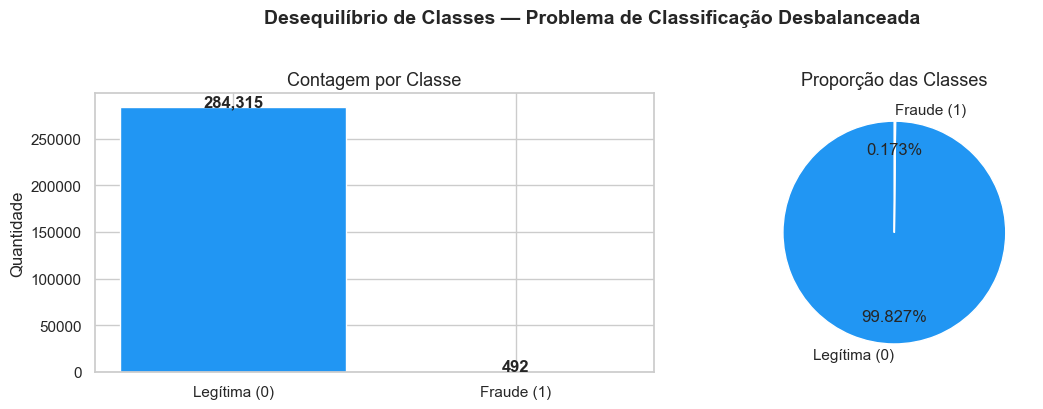

In [6]:
# Distribuição das classes
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('=== Distribuição das Classes ===')
print(f'Legítimas  (0): {class_counts[0]:>7,}  ({class_pct[0]:.4f}%)')
print(f'Fraudes    (1): {class_counts[1]:>7,}  ({class_pct[1]:.4f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem
axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Contagem por Classe', fontsize=13)
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Percentual (pizza)
axes[1].pie(class_counts.values, labels=['Legítima (0)', 'Fraude (1)'],
            autopct='%1.3f%%', colors=['#2196F3', '#F44336'],
            startangle=90, pctdistance=0.75)
axes[1].set_title('Proporção das Classes', fontsize=13)

plt.suptitle('Desequilíbrio de Classes — Problema de Classificação Desbalanceada',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

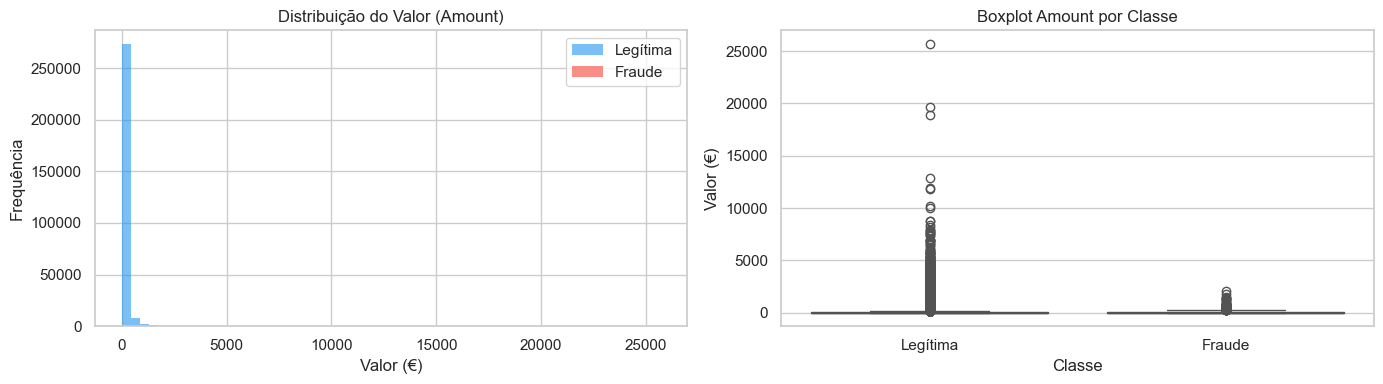

In [7]:
# Distribuição do valor (Amount) por classe
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, name, color in [(0, 'Legítima', '#2196F3'), (1, 'Fraude', '#F44336')]:
    subset = df[df['Class'] == label]['Amount']
    axes[0].hist(subset, bins=60, alpha=0.6, label=name, color=color, edgecolor='none')

axes[0].set_title('Distribuição do Valor (Amount)')
axes[0].set_xlabel('Valor (€)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot
df_plot = df.copy()
df_plot['Classe'] = df_plot['Class'].map({0: 'Legítima', 1: 'Fraude'})
sns.boxplot(data=df_plot, x='Classe', y='Amount', palette=['#2196F3', '#F44336'], ax=axes[1])
axes[1].set_title('Boxplot Amount por Classe')
axes[1].set_ylabel('Valor (€)')

plt.tight_layout()
plt.show()

## 1.3 Feature Engineering

- `Amount_log`: transformação logarítmica para reduzir assimetria
- `Amount_scaled`: escalonamento robusto (resistente a outliers)
- Remoção de `Time` (não informativo sem contexto temporal) e `Amount` original

In [8]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Executa o pré-processamento do dataset de transações.

    - Cria feature logarítmica de Amount
    - Escala Amount com RobustScaler
    - Remove colunas originais Time e Amount

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame bruto com colunas Time, Amount e V1-V28.

    Returns
    -------
    pd.DataFrame
        DataFrame processado pronto para modelagem.
    """
    df = df.copy()

    # Feature Engineering
    df['Amount_log'] = np.log1p(df['Amount'])

    scaler = RobustScaler()
    df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

    # Remover colunas que não usaremos diretamente
    df = df.drop(columns=['Time', 'Amount'])

    return df


df_processed = preprocess(df)
print(f'Shape após pré-processamento: {df_processed.shape}')
print(f'Colunas: {list(df_processed.columns)}')

Shape após pré-processamento: (284807, 31)
Colunas: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_log', 'Amount_scaled']


## 1.4 Divisão Treino / Teste

In [9]:
X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,  # preserva proporção de fraudes no split
)

print(f'Treino: {X_train.shape[0]:,} amostras')
print(f'Teste:  {X_test.shape[0]:,} amostras')
print(f'Fraudes no treino: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Fraudes no teste:  {y_test.sum()} ({y_test.mean()*100:.3f}%)')

Treino: 199,364 amostras
Teste:  85,443 amostras
Fraudes no treino: 344 (0.173%)
Fraudes no teste:  148 (0.173%)


## 1.5 Modelo Baseline — Regressão Logística

> **Atenção:** Acurácia não é a métrica correta para dados desbalanceados.  
> Um modelo que prevê **sempre 0 (legítima)** teria ~99.8% de acurácia — mas seria inútil para detectar fraudes.  
> Usaremos **Recall, Precision, F1** (fraude) e **ROC-AUC**.

In [10]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print('=== BASELINE — Regressão Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['Legítima', 'Fraude']))

roc_lr = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
print(f'ROC-AUC: {roc_lr:.4f}')

=== BASELINE — Regressão Logística ===
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     85295
      Fraude       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443

ROC-AUC: 0.9693


---
# MÓDULO 2 — Avaliação e Técnicas de Balanceamento
## 2.1 Funções de Avaliação Visual

In [11]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str = '') -> None:
    """Plota a matriz de confusão como heatmap.

    Parameters
    ----------
    y_true : np.ndarray
        Valores reais.
    y_pred : np.ndarray
        Valores previstos.
    title : str
        Título do gráfico.
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Legítima', 'Fraude'],
        yticklabels=['Legítima', 'Fraude'],
        ax=ax, linewidths=0.5,
    )
    ax.set_xlabel('Predito', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)
    ax.set_title(f'Matriz de Confusão\n{title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_roc(model, X_test: pd.DataFrame, y_test: pd.Series, label: str = '') -> None:
    """Plota a Curva ROC com AUC anotado.

    Parameters
    ----------
    model : estimator
        Modelo treinado com método predict_proba.
    X_test : pd.DataFrame
        Features do conjunto de teste.
    y_test : pd.Series
        Labels do conjunto de teste.
    label : str
        Nome do modelo para a legenda.
    """
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{label}  (AUC = {auc:.4f})', color='#1565C0')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.50)')
    plt.fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
    plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
    plt.title(f'Curva ROC — {label}', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_precision_recall(model, X_test: pd.DataFrame, y_test: pd.Series, label: str = '') -> None:
    """Plota a Curva Precision-Recall.

    Parameters
    ----------
    model : estimator
        Modelo treinado com método predict_proba.
    X_test : pd.DataFrame
        Features do conjunto de teste.
    y_test : pd.Series
        Labels do conjunto de teste.
    label : str
        Nome do modelo para a legenda.
    """
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, lw=2, color='#C62828',
             label=f'{label}  (AP = {ap:.4f})')
    plt.fill_between(recall, precision, alpha=0.08, color='#C62828')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Curva Precision-Recall — {label}', fontsize=13, fontweight='bold')
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()


def evaluate_model(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    label: str = 'Modelo',
) -> dict:
    """Avalia um modelo treinado gerando métricas e gráficos.

    Parameters
    ----------
    model : estimator
        Modelo treinado.
    X_test : pd.DataFrame
        Features do conjunto de teste.
    y_test : pd.Series
        Labels do conjunto de teste.
    label : str
        Nome descritivo do modelo.

    Returns
    -------
    dict
        Dicionário com roc_auc e average_precision.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f'\n{"="*50}')
    print(f'  {label}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))

    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    print(f'ROC-AUC:            {roc_auc:.4f}')
    print(f'Average Precision:  {ap:.4f}')

    plot_confusion_matrix(y_test, y_pred, title=label)
    plot_roc(model, X_test, y_test, label=label)
    plot_precision_recall(model, X_test, y_test, label=label)

    return {'roc_auc': roc_auc, 'average_precision': ap}


print('Funções de avaliação definidas.')

Funções de avaliação definidas.



  Regressão Logística (Baseline)
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     85295
      Fraude       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443

ROC-AUC:            0.9693
Average Precision:  0.7021


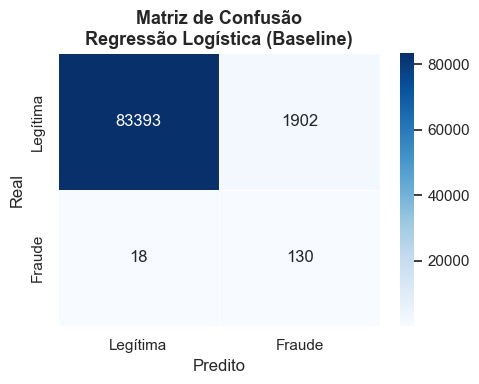

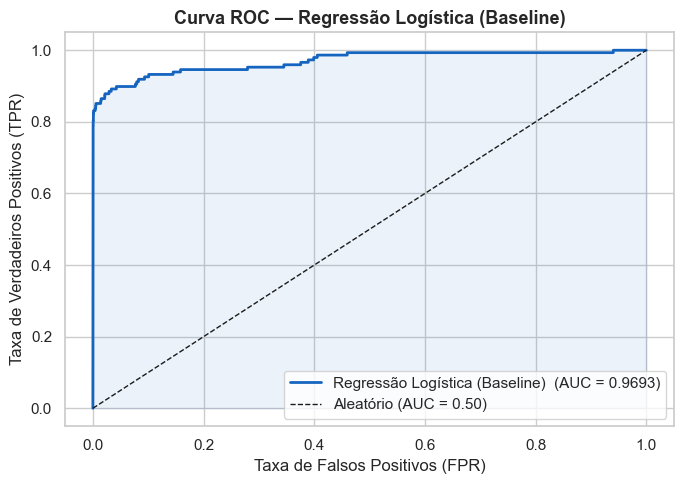

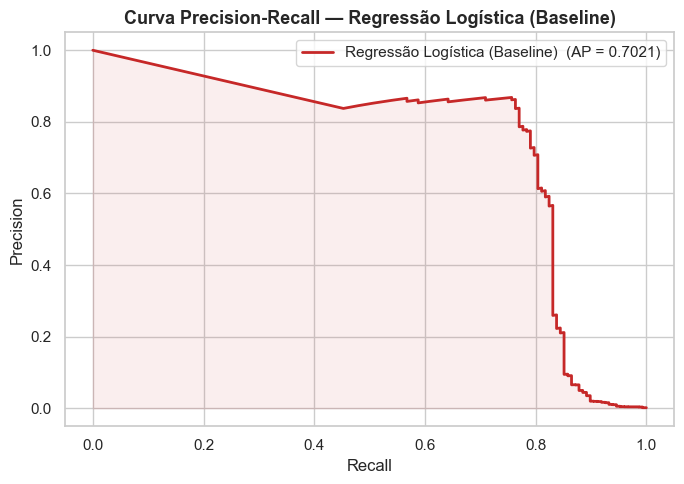

In [12]:
# Avaliação completa do baseline
metrics_lr = evaluate_model(lr_model, X_test, y_test, label='Regressão Logística (Baseline)')

## 2.2 Técnica 1 — Undersampling Manual

Reduzimos as transações legítimas para igualar a quantidade de fraudes.  
> **Desvantagem:** perda massiva de informação; útil apenas como referência.

In [13]:
fraud_df = df_processed[df_processed['Class'] == 1]
legit_df = df_processed[df_processed['Class'] == 0]

n_fraud = len(fraud_df)
legit_sample = legit_df.sample(n=n_fraud, random_state=RANDOM_STATE)

df_under = pd.concat([legit_sample, fraud_df]).sample(frac=1, random_state=RANDOM_STATE)

X_under = df_under.drop(columns=['Class'])
y_under = df_under['Class']

X_train_under, X_test_under, y_train_under, y_test_under = train_test_split(
    X_under, y_under,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_under,
)

print(f'Dataset balanceado por undersampling: {df_under.shape}')
print(f'Distribuição:\n{y_under.value_counts()}')

Dataset balanceado por undersampling: (984, 31)
Distribuição:
Class
1    492
0    492
Name: count, dtype: int64



  Regressão Logística + Undersampling
              precision    recall  f1-score   support

    Legítima       1.00      0.96      0.98     85295
      Fraude       0.04      0.91      0.07       148

    accuracy                           0.96     85443
   macro avg       0.52      0.93      0.52     85443
weighted avg       1.00      0.96      0.98     85443

ROC-AUC:            0.9851
Average Precision:  0.3497


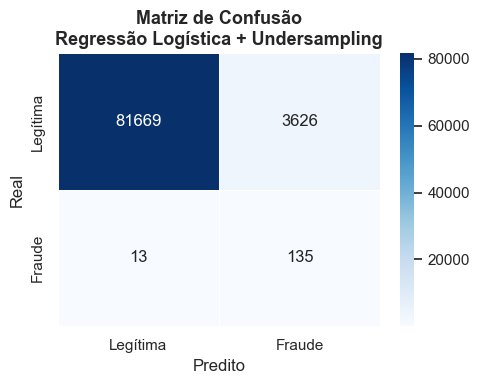

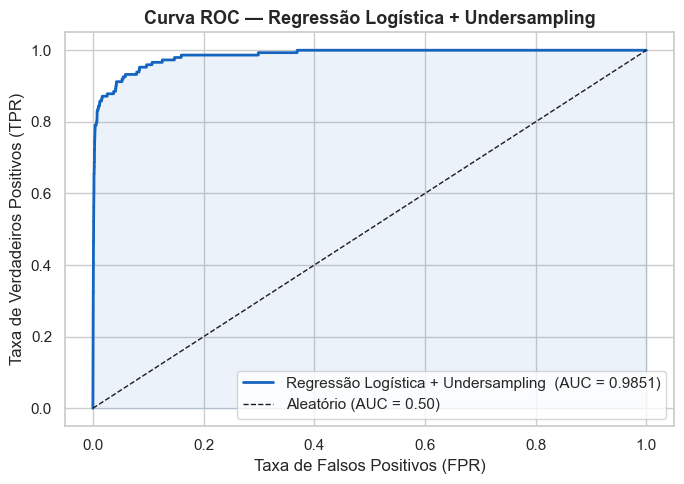

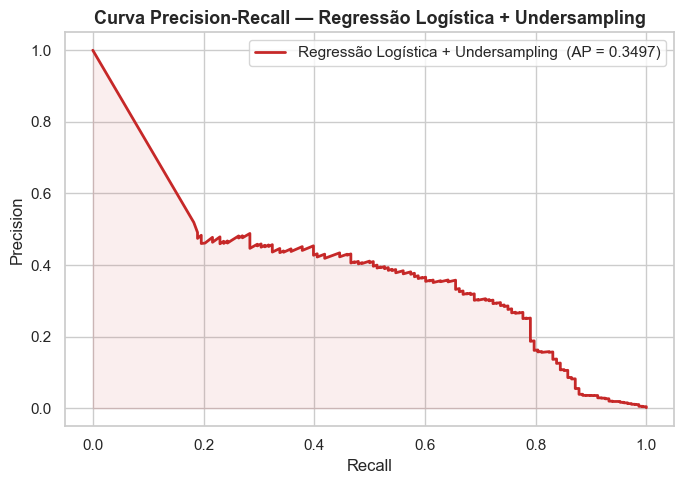

In [14]:
lr_under = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
lr_under.fit(X_train_under, y_train_under)

# Avaliar no conjunto de teste ORIGINAL (desbalanceado) — situação real
metrics_lr_under = evaluate_model(
    lr_under, X_test, y_test,
    label='Regressão Logística + Undersampling',
)

## 2.3 Técnica 2 — Oversampling com SMOTE

**SMOTE** (Synthetic Minority Oversampling Technique): gera amostras sintéticas da classe minoritária interpolando entre vizinhos reais.  
> **Vantagem:** não descarta dados; **cuidado:** aplicar SMOTE apenas no treino para evitar data leakage.

In [15]:
smote = SMOTE(
    sampling_strategy=SMOTE_SAMPLING_STRATEGY,
    random_state=RANDOM_STATE,
    k_neighbors=5,
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Treino antes do SMOTE: {X_train.shape[0]:,} amostras')
print(f'Treino após o SMOTE:   {X_train_smote.shape[0]:,} amostras')
print(f'Fraudes após SMOTE: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.1f}%)')

Treino antes do SMOTE: 199,364 amostras
Treino após o SMOTE:   298,530 amostras
Fraudes após SMOTE: 99,510 (33.3%)



  Regressão Logística + SMOTE
              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99     85295
      Fraude       0.12      0.85      0.20       148

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.60     85443
weighted avg       1.00      0.99      0.99     85443

ROC-AUC:            0.9674
Average Precision:  0.7010


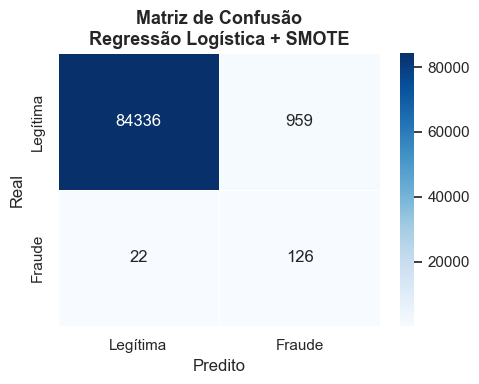

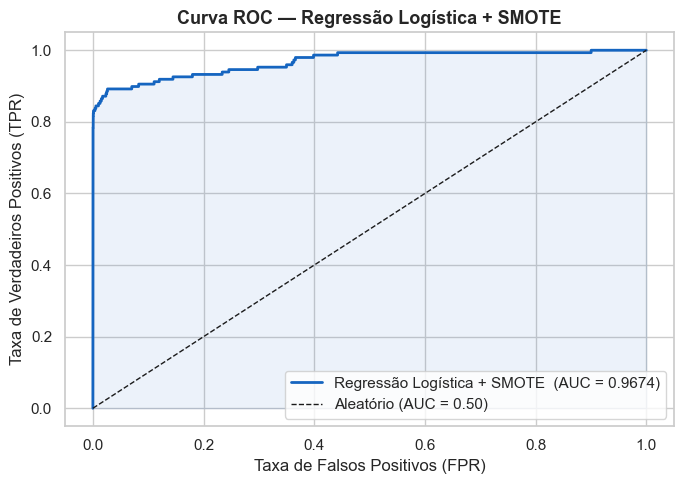

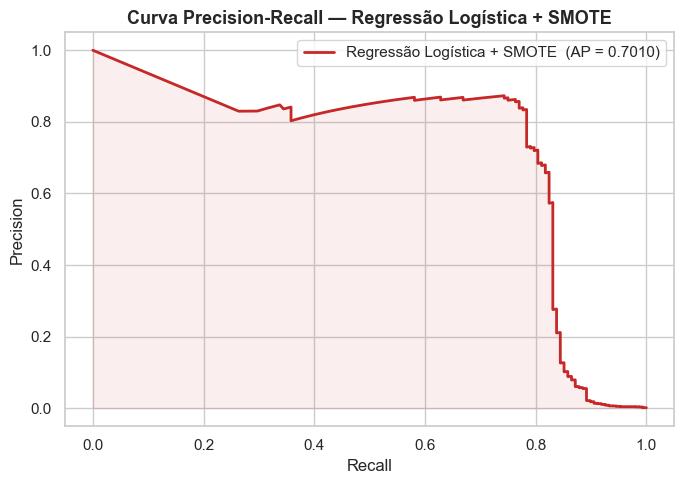

In [16]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
lr_smote.fit(X_train_smote, y_train_smote)

metrics_lr_smote = evaluate_model(
    lr_smote, X_test, y_test,
    label='Regressão Logística + SMOTE',
)

## 2.4 Random Forest com class_weight='balanced'


  Random Forest (class_weight=balanced)
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     85295
      Fraude       0.85      0.78      0.81       148

    accuracy                           1.00     85443
   macro avg       0.92      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC:            0.9589
Average Precision:  0.7726


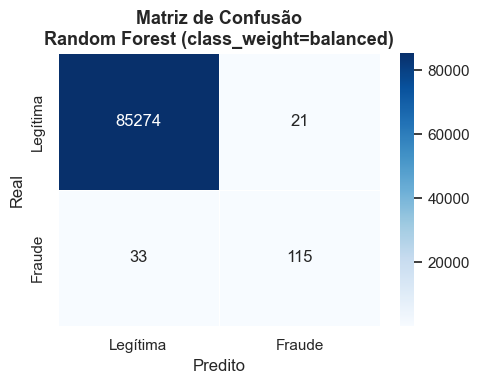

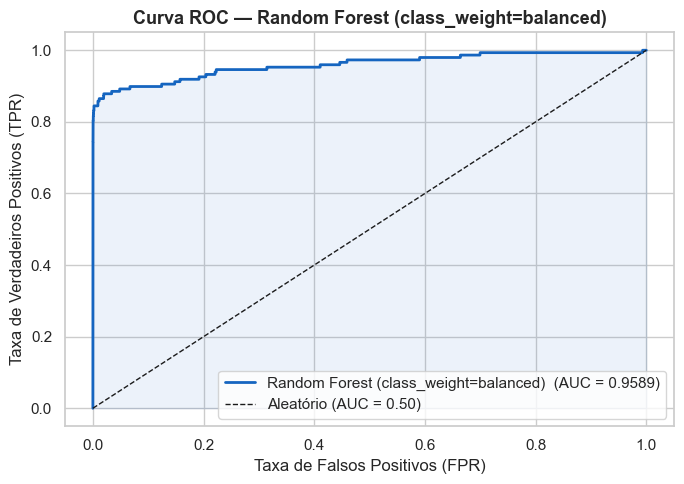

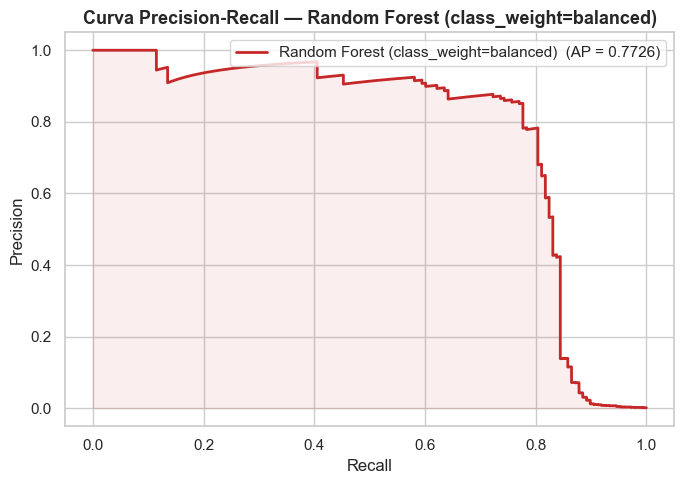

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

metrics_rf = evaluate_model(
    rf_model, X_test, y_test,
    label='Random Forest (class_weight=balanced)',
)


  Random Forest + SMOTE
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     85295
      Fraude       0.62      0.81      0.71       148

    accuracy                           1.00     85443
   macro avg       0.81      0.90      0.85     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC:            0.9782
Average Precision:  0.7915


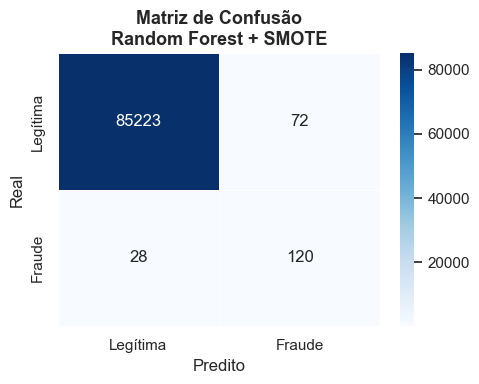

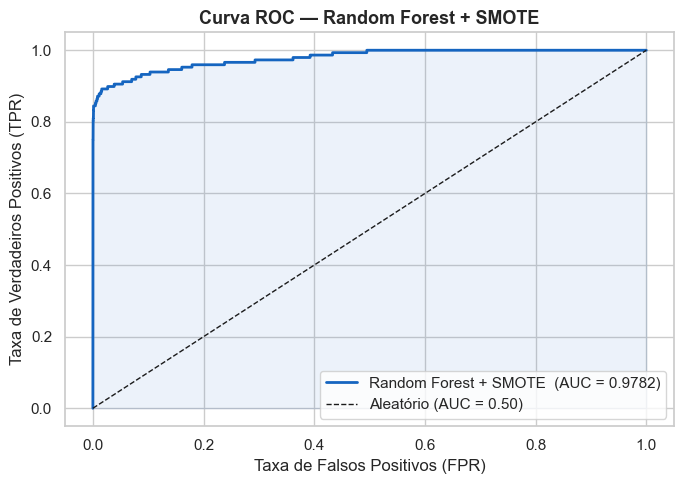

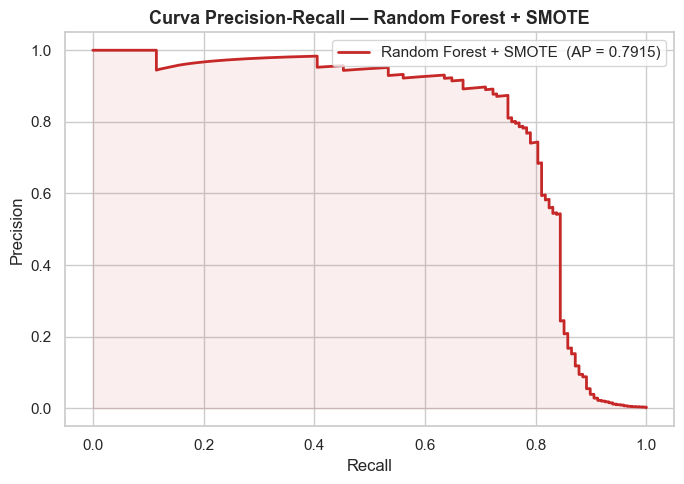

In [18]:
# Random Forest + SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_smote.fit(X_train_smote, y_train_smote)

metrics_rf_smote = evaluate_model(
    rf_smote, X_test, y_test,
    label='Random Forest + SMOTE',
)

## 2.5 Comparativo de Modelos

=== Comparativo de Métricas ===
                     roc_auc  average_precision
Modelo                                         
LR Baseline         0.969322           0.702098
LR + Undersampling  0.985088           0.349737
LR + SMOTE          0.967406           0.700962
RF Balanced         0.958911           0.772612
RF + SMOTE          0.978186           0.791523


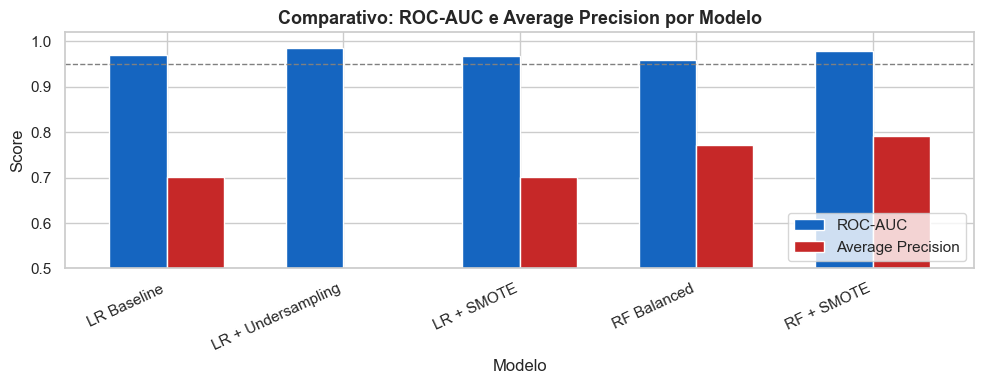

In [19]:
comparison = pd.DataFrame([
    {'Modelo': 'LR Baseline',          **metrics_lr},
    {'Modelo': 'LR + Undersampling',   **metrics_lr_under},
    {'Modelo': 'LR + SMOTE',           **metrics_lr_smote},
    {'Modelo': 'RF Balanced',          **metrics_rf},
    {'Modelo': 'RF + SMOTE',           **metrics_rf_smote},
]).set_index('Modelo')

print('=== Comparativo de Métricas ===')
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
comparison.plot(kind='bar', ax=ax, color=['#1565C0', '#C62828'], edgecolor='white', width=0.65)
ax.set_title('Comparativo: ROC-AUC e Average Precision por Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.02)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(['ROC-AUC', 'Average Precision'], loc='lower right')
ax.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='Meta ROC-AUC 0.95')
plt.tight_layout()
plt.show()

---
# MÓDULO 3 — Modelos Avançados e Explicabilidade
## 3.1 Importância das Variáveis

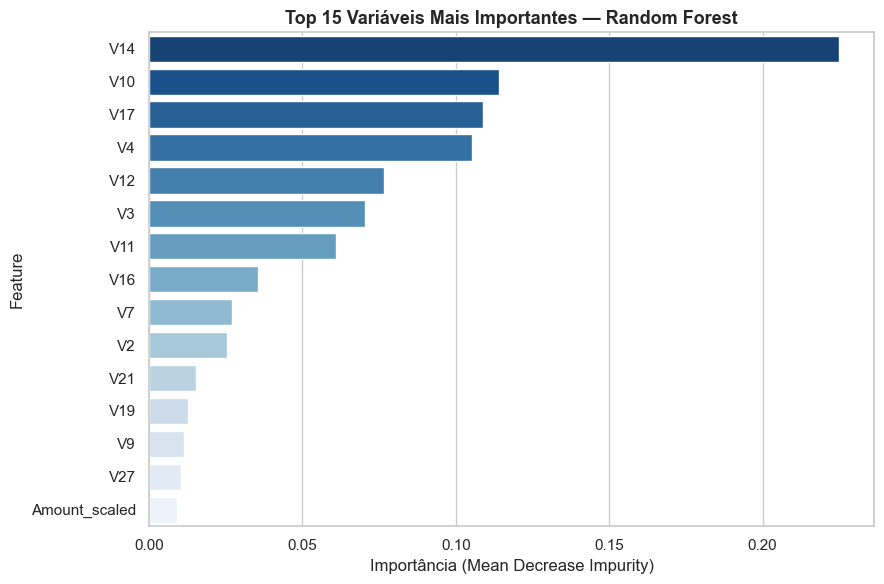

In [20]:
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_

feat_importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=feat_importance_df,
    x='Importance', y='Feature',
    palette='Blues_r', ax=ax,
)
ax.set_title('Top 15 Variáveis Mais Importantes — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (Mean Decrease Impurity)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 3.2 Ajuste de Hiperparâmetros — RandomizedSearchCV

In [ ]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(f'Melhores hiperparâmetros: {random_search.best_params_}')
print(f'Melhor ROC-AUC (CV):    {random_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
best_rf = random_search.best_estimator_

metrics_best_rf = evaluate_model(
    best_rf, X_test, y_test,
    label='Random Forest — Melhor Modelo (RandomizedSearchCV)',
)

## 3.3 Explicabilidade com SHAP

**SHAP** (SHapley Additive exPlanations) atribui a cada feature uma contribuição para a previsão do modelo, baseado na teoria dos jogos cooperativos.  
- Valores SHAP positivos → aumentam a probabilidade de fraude
- Valores SHAP negativos → diminuem a probabilidade de fraude

In [ ]:
# Usar amostra para tornar o SHAP mais rápido
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sample)

print('SHAP values calculados.')
print(f'Shape dos SHAP values: {np.array(shap_values).shape}')

In [ ]:
# Summary Plot — impacto geral das features
plt.figure()
shap.summary_plot(
    shap_values[1],  # classe 1 = fraude
    X_test_sample,
    plot_type='bar',
    show=False,
    max_display=15,
)
plt.title('SHAP — Importância Global das Features (Fraude)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Beeswarm plot — distribuição e direção do impacto
plt.figure()
shap.summary_plot(
    shap_values[1],
    X_test_sample,
    show=False,
    max_display=15,
)
plt.title('SHAP Beeswarm — Direção do Impacto por Feature (Fraude)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3.4 Avaliação Final — Resumo Executivo

In [ ]:
from sklearn.metrics import classification_report

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

final_roc_auc = roc_auc_score(y_test, y_proba_best)
final_ap = average_precision_score(y_test, y_proba_best)

print('=' * 60)
print('  RESULTADO FINAL — MELHOR MODELO')
print('=' * 60)
print(classification_report(y_test, y_pred_best, target_names=['Legítima', 'Fraude']))
print(f'ROC-AUC:            {final_roc_auc:.4f}')
print(f'Average Precision:  {final_ap:.4f}')
print('=' * 60)

# Verificação das metas
from sklearn.metrics import recall_score, precision_score
recall_fraud = recall_score(y_test, y_pred_best, pos_label=1)

print('\n--- Verificação de Metas ---')
print(f'ROC-AUC > 0.95:        {"✓" if final_roc_auc > 0.95 else "✗"}  ({final_roc_auc:.4f})')
print(f'Recall (fraude) > 0.70: {"✓" if recall_fraud > 0.70 else "✗"}  ({recall_fraud:.4f})')
print(f'AP > 0.80:             {"✓" if final_ap > 0.80 else "✗"}  ({final_ap:.4f})')

---
## Conclusão

### O que aprendemos

1. **Dados desbalanceados são o maior desafio** — acurácia não é métrica válida; usamos Recall, Precision e ROC-AUC.
2. **Técnicas de balanceamento** têm trade-offs:
   - Undersampling: rápido, mas perde informação
   - SMOTE: preserva dados, gera exemplos sintéticos realistas
   - `class_weight='balanced'`: penaliza erros na classe minoritária automaticamente
3. **Random Forest supera Regressão Logística** neste problema pela capacidade de capturar relações não-lineares nas features PCA.
4. **SHAP** torna o modelo explicável, mostrando quais features contribuem para cada predição de fraude.
5. **Boas práticas** (funções modulares, constantes, `random_state`, sem data leakage) garantem reprodutibilidade e qualidade do código.

### Próximos Passos Possíveis
- Testar XGBoost/LightGBM para ganho adicional de performance
- Implementar threshold tuning (ajustar o limiar de decisão para maximizar o F1 na fraude)
- Monitoramento de data drift em produção
- API REST com FastAPI para servir o modelo